In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [4]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [6]:
docs_with_topic=pd.read_csv("../Output/NLP Output/feature_extraction_origin.csv", usecols=["LSOA21CD", "year", "description", "topic"])

In [17]:
topic = pd.read_csv("../Output/NLP Output/topic_info_origin.csv", usecols=["Representation"])
topic_with_rm = pd.read_csv("../Output/NLP Output/topic_info_rm_gpt4omini.csv", usecols=["Topic", "Representation"])

In [18]:
topic.rename(columns={"Representation": "Keywords"}, inplace=True)

In [19]:
topic_detail = pd.concat([topic_with_rm, topic], axis=1)

In [28]:
docs_with_rm = pd.merge(docs_with_topic, topic_detail, left_on='topic', right_on='Topic')
docs_with_rm.drop(columns=['topic'], inplace=True)

In [31]:
gen_class_5 = pd.read_csv("../Output/Gentrification label_2021_5class.csv")

In [32]:
docs_with_rm_5class = pd.merge(docs_with_rm, gen_class_5, on='LSOA21CD', how='left')

In [33]:
docs_with_rm_5class

,LSOA21CD,year,description,Topic,Representation,Keywords,gentrification_class
0,E01033084,2002,Change of use from guest house to 5 flats.,31,['Conversion of Flats to Single Family Dwelling'],"['flats single', 'house change', 'use flats', ...",Class 3 - At Risk of Gentrification
1,E01002676,2002,Demolition of existing house and erection of 4...,-1,['Residential Conversion and Redevelopment Pro...,"['ground', 'building', 'floor', 'units', 'grou...",Class 0 - Stable Affluent and Moderate-income
2,E01002662,2002,Erection of single storey rear extension and c...,467,['Rear Extension and Conversion of House into ...,"['bed erection', 'conversion dwelling', 'exten...",Class 3 - At Risk of Gentrification
3,E01002687,2002,Change of use from office to 2 bed maisonette.,0,['Conversion of Maisonettes into Self-Containe...,"['maisonette', 'floor maisonette', 'bedroom ma...",Class 0 - Stable Affluent and Moderate-income
4,E01002649,2002,Conversion from retail unit to 1 bed flat and ...,-1,['Residential Conversion and Redevelopment Pro...,"['ground', 'building', 'floor', 'units', 'grou...",Class 3 - At Risk of Gentrification
...,...,...,...,...,...,...,...
113933,E01000638,2021,Change of use of first and second floors offic...,18,['Conversion of Office Space to Residential Un...,"['class b1', 'office class', 'b1 residential',...",Class 3 - At Risk of Gentrification
113934,E01000488,2021,Certificate of lawfulness for existing use as ...,-1,['Residential Conversion and Redevelopment Pro...,"['ground', 'building', 'floor', 'units', 'grou...",Class 2 - Ongoing Displacement
113935,E01034149,2021,Erection of mansard roof over whole building t...,2,['Mansard Roof Extensions for Additional Resid...,"['mansard', 'mansard roof', 'erection mansard'...",Class 0 - Stable Affluent and Moderate-income
113936,E01000643,2021,Prior approval for the construction of new dwe...,-1,['Residential Conversion and Redevelopment Pro...,"['ground', 'building', 'floor', 'units', 'grou...",Class 3 - At Risk of Gentrification


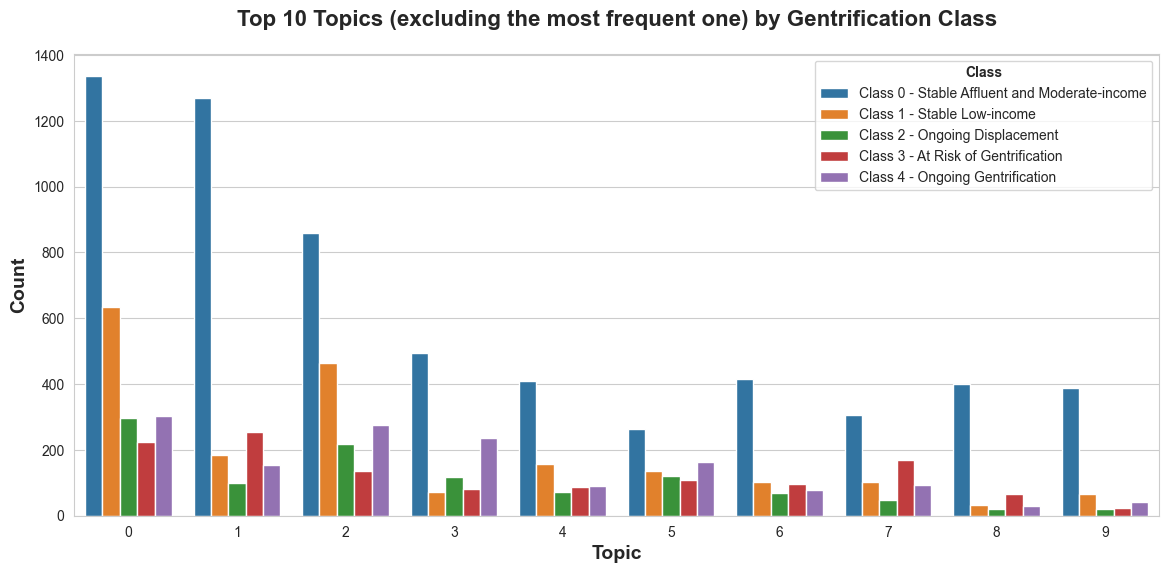

In [ ]:
import matplotlib.font_manager as fm

bold_font = fm.FontProperties(weight='bold')

import seaborn as sns
import matplotlib.pyplot as plt

df_period = docs_with_rm_5class[(docs_with_rm_5class["year"] >= 2002) & (docs_with_rm_5class["year"] <= 2011)]
top_topics = df_period["Topic"].value_counts().head(11).index[1:]

# Step 1: Count topic frequencies and exclude the first most frequent topic
top_topics = (
    docs_with_rm_5class["Topic"]
    .value_counts()
    .iloc[1:11]   # Skip the first one and take the next 10 most frequent topics
    .index
)

# Step 2: Filter the dataset to only include the selected top topics
df_top = docs_with_rm_5class[docs_with_rm_5class["Topic"].isin(top_topics)]

# Step 3: Create a count plot of topic distribution by gentrification class
plt.figure(figsize=(14,6))
sns.countplot(
    data=df_top,
    x="Topic",
    hue="gentrification_class",
    order=top_topics  # Ensure topics are ordered by their frequency
)

# Step 4: Customize chart title and labels
plt.title("Top 10 Topics (excluding the most frequent one) by Gentrification Class", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Topic", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.legend(title="Class", title_fontproperties=bold_font, bbox_to_anchor=(1, 1))
plt.show()

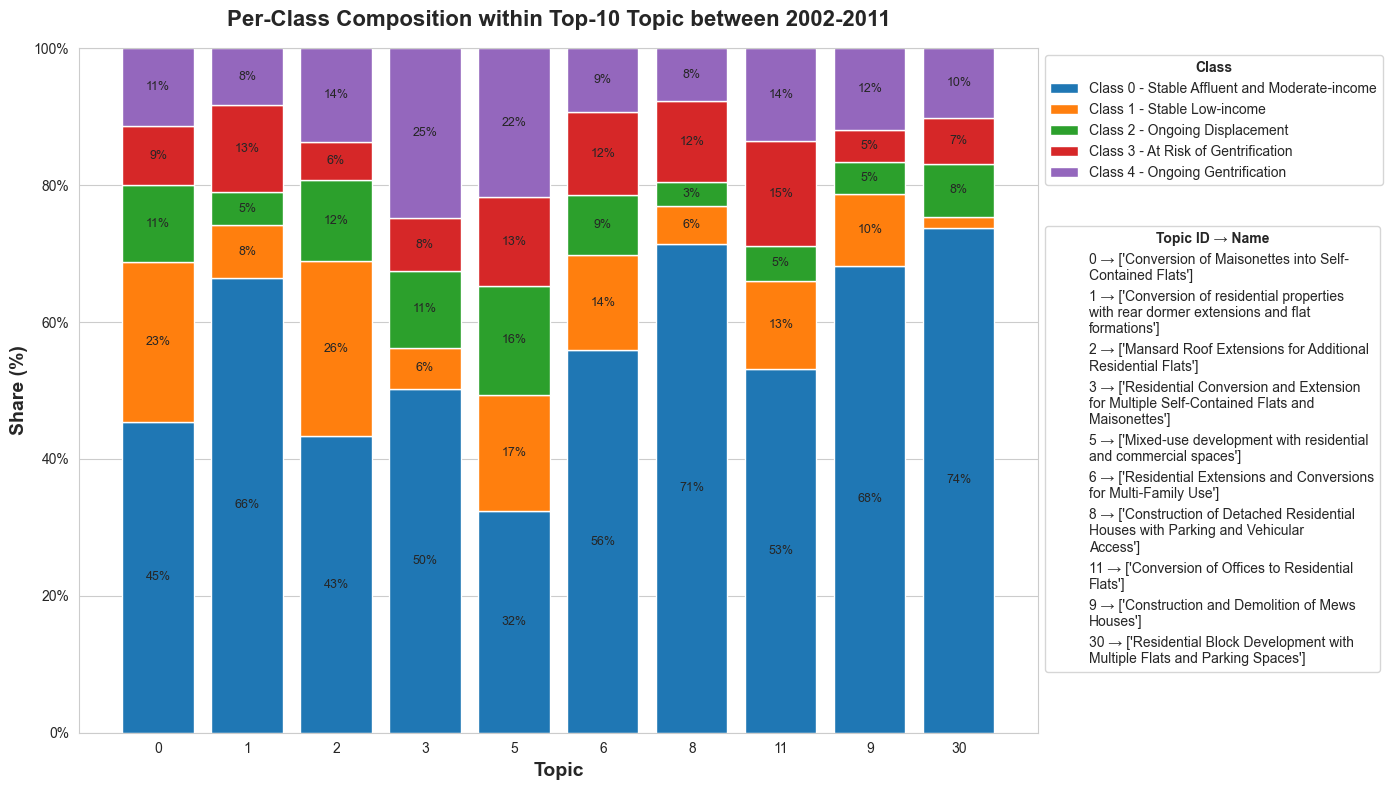

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import textwrap

# -------------------- Style --------------------
sns.set_style("whitegrid")                      # Light grid on white background
bold_font = fm.FontProperties(weight='bold')    # Bold font for legend titles

# -------------------- Base data --------------------
df = docs_with_rm_5class.copy()

# 1) Restrict to 2002–2011
df_period = df[(df["year"] >= 2002) & (df["year"] <= 2011)]

# 2) Pick top-11 topics within the period, then drop the most frequent -> keep 10 topics
top_topics = df_period["Topic"].value_counts().head(11).index[1:]

# 3) Keep only those topics
df_top = df_period[df_period["Topic"].isin(top_topics)].copy()

# 4) Count Topic × Class, then row-normalize (per-topic percentages)
counts = (
    df_top
    .groupby(["Topic", "gentrification_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_topics)  # keep topic order = frequency order (after excluding the 1st)
)
props = counts.div(counts.sum(axis=1), axis=0)

# -------------------- Plot --------------------
# Make the figure taller and reserve space on the right for legends
fig, ax = plt.subplots(figsize=(14, 8))
fig.subplots_adjust(right=0.7)  # shrink plot width; right 30% reserved for legends

x = np.arange(len(props.index))
width = 0.8

bottom = np.zeros(len(x))
for cls in props.columns:
    vals = props[cls].values
    bars = ax.bar(x, vals, width=width, bottom=bottom, label=cls)
    # Put percentage labels centered on each visible segment
    for i, b in enumerate(bars):
        pct = vals[i] * 100
        if pct >= 3:  # skip tiny slivers to avoid clutter; adjust threshold if needed
            ax.text(
                b.get_x() + b.get_width()/2,
                bottom[i] + vals[i]/2,
                f"{pct:.0f}%",
                ha="center", va="center", fontsize=9
            )
    bottom += vals

# X-axis ticks: keep Topic IDs (you also have a mapping legend below)
ax.set_xticks(x)
ax.set_xticklabels(props.index, rotation=0)

# Y-axis as percentage
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0, 1)

# Titles and labels
ax.set_title(
    "Per-Class Composition within Top-10 Topic between 2002-2011",
    fontsize=16, pad=16, fontweight='bold'
)
ax.set_xlabel("Topic", fontsize=14, fontweight='bold')
ax.set_ylabel("Share (%)", fontsize=14, fontweight='bold')

# -------------------- Legend 1: Class --------------------
leg1 = ax.legend(
    title="Class",
    bbox_to_anchor=(1, 1),  # right side, top
    loc="upper left"
)
leg1.get_title().set_fontproperties(bold_font)
ax.add_artist(leg1)  # fix leg1 in place so we can add another legend

# -------------------- Topic ID → Name mapping legend --------------------
# Build Topic -> wrapped name mapping from Representation
topic_map = (
    df[["Topic", "Representation"]]
    .drop_duplicates()
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda r: r[0] if isinstance(r, list) else r  # take first if it's a list
    ))
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda s: textwrap.fill(s if isinstance(s, str) else "", width=40)  # wrap long titles
    ))
    .set_index("Topic")["Representation"]
    .to_dict()
)

# Create transparent handles to show mapping lines
topic_mapping_handles = []
for topic_id in top_topics:
    label = f"{topic_id} → {topic_map.get(topic_id, '')}"
    topic_mapping_handles.append(mpatches.Patch(color="none", label=label))

# Legend 2 placed directly below Legend 1
leg2 = ax.legend(
    handles=topic_mapping_handles,
    title="Topic ID → Name",
    bbox_to_anchor=(1, 0.75),
    loc="upper left",
    # frameon=False,
    ncol=1
)
leg2.get_title().set_fontproperties(bold_font)

plt.tight_layout()
plt.show()


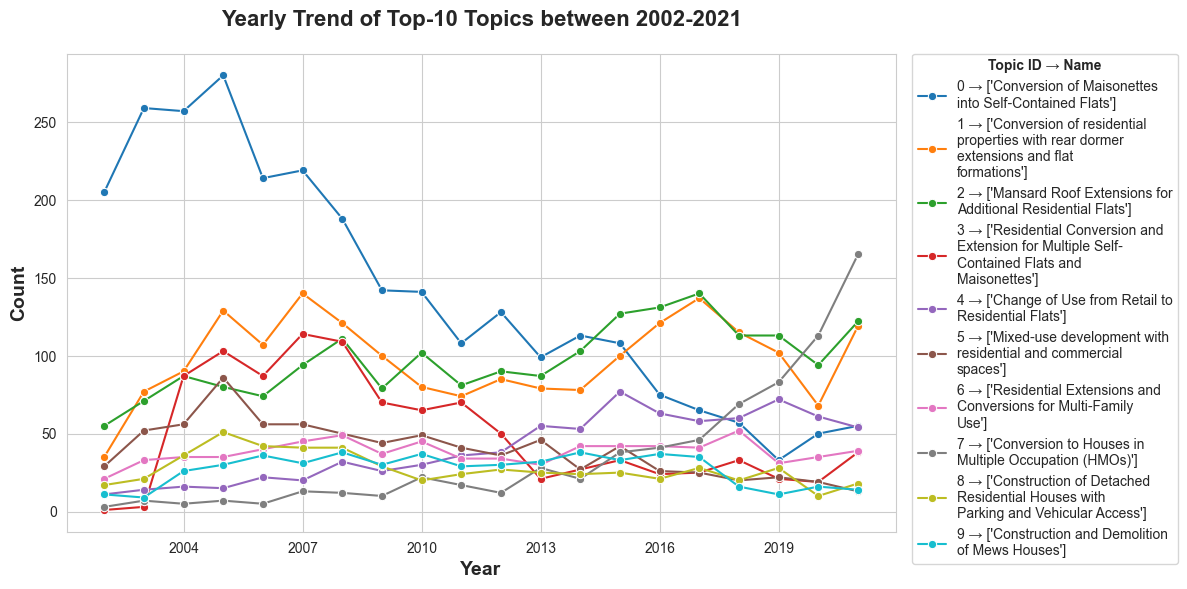

In [ ]:
# Build mapping: Topic -> Representation text with line breaks
topic_map = (
    docs_with_rm_5class[["Topic", "Representation"]]
    .drop_duplicates()
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda r: r[0] if isinstance(r, list) else r
    ))
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda s: textwrap.fill(s, width=30)  # wrap every 30 characters
    ))
    .set_index("Topic")["Representation"]
    .to_dict()
)

# Pick top-11 topics, drop the most frequent one -> remain 10 topics
top_topics = docs_with_rm_5class["Topic"].value_counts().head(11).index[1:]

# Filter dataset for these topics
df_top = docs_with_rm_5class[docs_with_rm_5class["Topic"].isin(top_topics)].copy()

# Count per (year, topic)
trend = df_top.groupby(["year", "Topic"]).size()

# Create full year×topic grid and fill missing combinations with 0
years = sorted(df_top["year"].unique())
idx = pd.MultiIndex.from_product([years, top_topics], names=["year", "Topic"])
trend = trend.reindex(idx, fill_value=0).reset_index(name="count")

# Map Topic IDs to wrapped names with ID in front
trend["Topic_Name"] = trend["Topic"].apply(
    lambda t: f"{t} → {topic_map.get(t, '')}"
)

# Ensure fixed hue order based on mapped names with IDs
hue_order = [f"{t} → {topic_map.get(t, '')}" for t in top_topics]

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
sns.lineplot(
    data=trend,
    x="year",
    y="count",
    hue="Topic_Name",   # Now legend will use the new "ID → Name" labels
    hue_order=hue_order,
    marker="o"
)

plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.title("Yearly Trend of Top-10 Topics between 2002-2021", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Year", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.legend(
    title="Topic ID → Name",
    title_fontproperties=bold_font,
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.tight_layout()
plt.show()

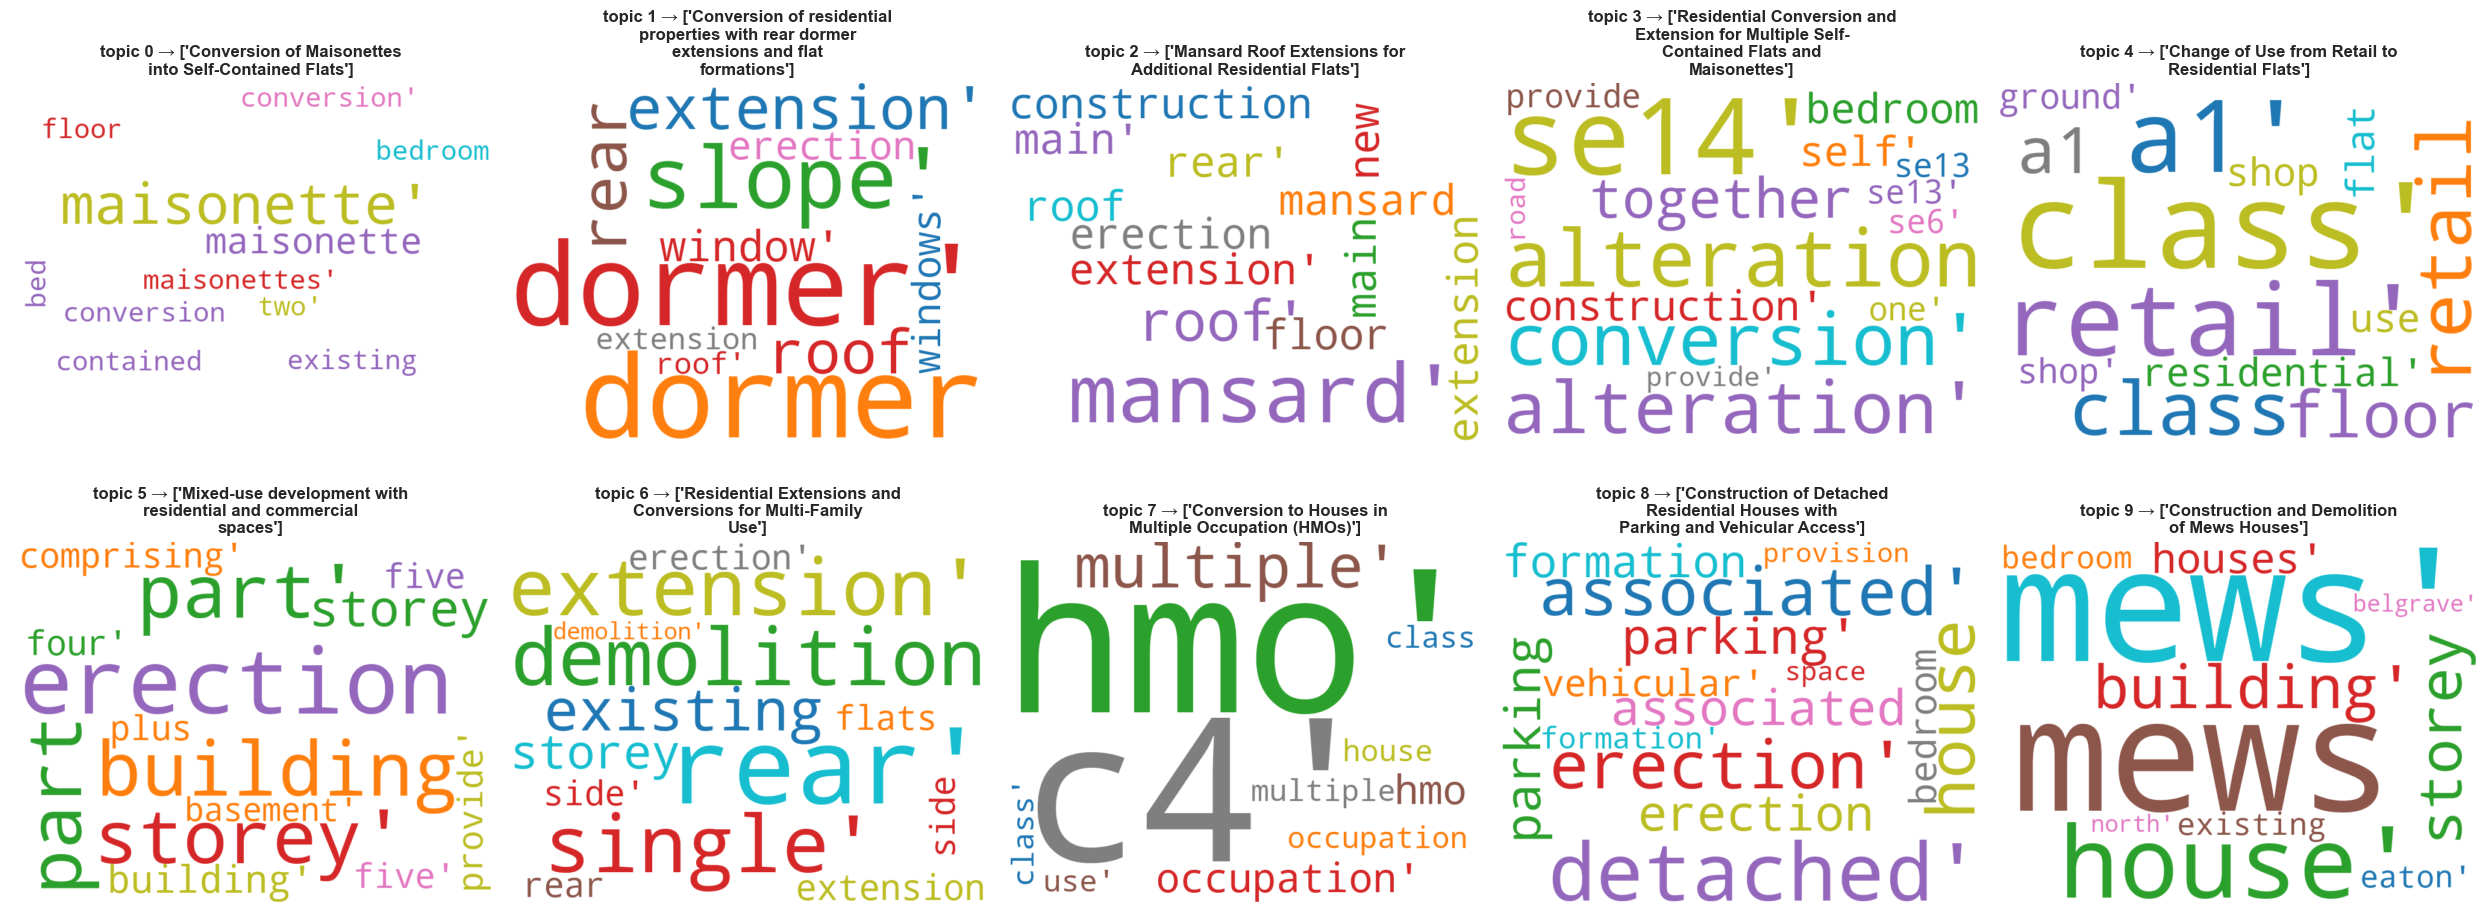

In [ ]:
from wordcloud import WordCloud

# Pick top-11 topics, drop the most frequent one
top_topics = docs_with_rm_5class["Topic"].value_counts().head(11).index[1:]

# Filter dataset for these topics ---
df_top = docs_with_rm_5class[docs_with_rm_5class["Topic"].isin(top_topics)]

# Build Topic ID -> wrapped Representation mapping
topic_map = (
    docs_with_rm_5class[["Topic", "Representation"]]
    .drop_duplicates()
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda r: r[0] if isinstance(r, list) else r  # take first element if list
    ))
    .assign(Representation=lambda x: x["Representation"].apply(
        lambda s: textwrap.fill(s, width=30)  # wrap at 30 characters
    ))
    .set_index("Topic")["Representation"]
    .to_dict()
)

# Create subplots: 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, topic_id in enumerate(top_topics):
    # Filter data for this topic
    topic_df = df_top[df_top["Topic"] == topic_id]
    
    # Combine all keywords into a single string
    keywords_text = " ".join([
        " ".join(kw) if isinstance(kw, list) else str(kw)
        for kw in topic_df["Keywords"]
    ])
    
    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=600,
        background_color="white",
        colormap="tab10",
        collocations=False
    ).generate(keywords_text)
    

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"topic {topic_id} → {topic_map.get(topic_id, '')}",
                      fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()